# Signature Forgery Detection - ResNet50
**42028 Deep Learning and CNNs**  
Team: The Sky is Blue

This notebook implements a ResNet50 transfer learning model for binary classification of handwritten signatures (genuine vs forged) using the combined CEDAR and Real-Fake Signature dataset.

## 0.1 Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Imports

In [ ]:
!pip install numpy matplotlib seaborn torch torchvision scikit-learn opencv-python-headless -q

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import cv2
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torch.nn.functional import cosine_similarity
from torchvision.models import ResNet50_Weights

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Dataset

In [ ]:
COMBINED_PATH = '/content/drive/MyDrive/forged-signature-models/combined_signature_dataset_renamed'

print('Dataset exists:', os.path.exists(COMBINED_PATH))
for cls in ['forged', 'genuine']:
    count = len(os.listdir(os.path.join(COMBINED_PATH, cls)))
    print(f'  {cls}: {count} images')

Dataset exists: True
  forged: 2728 images
  genuine: 2728 images


## 3. Data Preprocessing & Augmentation

In [ ]:
# Load transforms (defined here so they are available before split cell)
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=COMBINED_PATH, transform=val_test_transforms)
print(f'Total combined images: {len(full_dataset)}')
print(f'Classes: {full_dataset.classes}')

Total combined images: 5456
Classes: ['forged', 'genuine']


## 4. Train / Validation / Test Split (80/10/10)

In [ ]:
def get_signer_id(filepath):
    filename = os.path.basename(filepath)
    name = os.path.splitext(filename)[0]

    if name.startswith('cedar_original_') or name.startswith('cedar_forgeries_'):
        parts = name.split('_')
        return f'cedar_{parts[2]}'

    elif name.startswith('rf_'):
        core = name[3:] # strip 'rf_' → e.g. '01F2'
        signer_num = ''
        for char in core:
            if char.isdigit():
                signer_num += char
            else:
                break
        if not signer_num:
            raise ValueError(f'Cannot parse signer number from: {filename}')
        return f'rf_{signer_num}'

    raise ValueError(f'Unknown filename format: {filename}')

# Build signer list (sort before shuffle for full reproducibility)
all_paths = [s[0] for s in full_dataset.samples]
signer_ids = sorted(set(get_signer_id(p) for p in all_paths))

print(f'Total unique signers: {len(signer_ids)}')

random.seed(42)
random.shuffle(signer_ids)

n = len(signer_ids)
train_signers = set(signer_ids[:int(0.8 * n)])
val_signers = set(signer_ids[int(0.8 * n):int(0.9 * n)])
test_signers = set(signer_ids[int(0.9 * n):])

print(f'Signers — Train: {len(train_signers)} | Val: {len(val_signers)} | Test: {len(test_signers)}')

# Safe per-split datasets — each has its own transform instance
class SignatureDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# Assign samples to splits
train_samples, val_samples, test_samples = [], [], []

for path, label in full_dataset.samples:
    sid = get_signer_id(path)
    if sid in train_signers:
        train_samples.append((path, label))
    elif sid in val_signers:
        val_samples.append((path, label))
    else:
        test_samples.append((path, label))

train_dataset = SignatureDataset(train_samples, transform=train_transforms)
val_dataset = SignatureDataset(val_samples, transform=val_test_transforms)
test_dataset = SignatureDataset(test_samples, transform=val_test_transforms)

print(f'Images  — Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

# Leakage verification
def get_split_signers(samples):
    return set(get_signer_id(p) for p, _ in samples)

assert len(get_split_signers(train_samples) & get_split_signers(val_samples)) == 0, 'LEAKAGE: train/val!'
assert len(get_split_signers(train_samples) & get_split_signers(test_samples)) == 0, 'LEAKAGE: train/test!'
assert len(get_split_signers(val_samples) & get_split_signers(test_samples)) == 0, 'LEAKAGE: val/test!'
print('Leakage check passed ✓')

# DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Total unique signers: 96
Signers — Train: 76 | Val: 10 | Test: 10
Images  — Train: 4398 | Val: 500 | Test: 558
Leakage check passed ✓

  Split  |  Genuine |   Forged | Ratio G:F
  -------+----------+----------+-----------
  Train  |     2211 |     2187 | 1.01
  Val    |      235 |      265 | 0.89
  Test   |      282 |      276 | 1.02


## 5. Visualise Sample Images

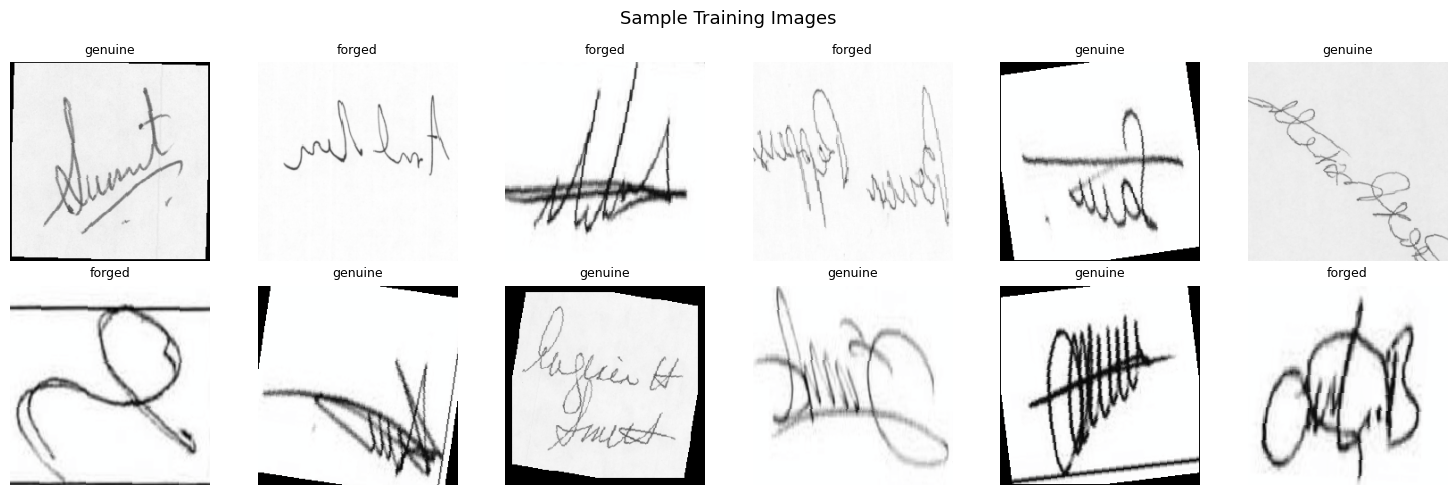

In [ ]:
class_names = full_dataset.classes

def imshow(img, title):
    # Undo normalisation for display
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.clip(std * img + mean, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Build ResNet50 Model

We load pretrained ResNet50 weights (ImageNet), freeze the convolutional base, and replace the final fully connected layer with a binary classification head.

In [ ]:
def build_resnet50(freeze_base=True):
    # Load pretrained ResNet50
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

    # Freeze all base layers
    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the final FC layer with a custom classification head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 1)  # Binary output (sigmoid applied in loss)
    )

    return model

model = build_resnet50(freeze_base=True).to(device)
print(model.fc)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 148MB/s]


Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=512, out_features=1, bias=True)
)

Total params:     24,557,633
Trainable params: 1,049,601


## 7. Training Setup

In [ ]:
criterion = nn.BCEWithLogitsLoss()  # Binary cross-entropy with logits
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)

# Reduce LR if validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

NUM_EPOCHS = 30
PATIENCE = 7 # Early stopping patience
best_val_loss = float('inf')
patience_counter = 0
best_model_path = 'best_resnet50.pth'

## 8. Training Loop (Phase 1 — Frozen Base)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('Phase 1: Training classification head (base frozen)\n')

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f'  --> Best model saved')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

print('\nPhase 1 complete.')

Phase 1: Training classification head (base frozen)

Epoch [01/30]  Train Loss: 0.6054  Train Acc: 0.6698  Val Loss: 0.5166  Val Acc: 0.7480
  --> Best model saved
Epoch [02/30]  Train Loss: 0.5104  Train Acc: 0.7535  Val Loss: 0.4560  Val Acc: 0.8040
  --> Best model saved
Epoch [03/30]  Train Loss: 0.4848  Train Acc: 0.7581  Val Loss: 0.4487  Val Acc: 0.7640
  --> Best model saved
Epoch [04/30]  Train Loss: 0.4582  Train Acc: 0.7747  Val Loss: 0.4166  Val Acc: 0.8160
  --> Best model saved
Epoch [05/30]  Train Loss: 0.4389  Train Acc: 0.7810  Val Loss: 0.3938  Val Acc: 0.8300
  --> Best model saved
Epoch [06/30]  Train Loss: 0.4266  Train Acc: 0.7842  Val Loss: 0.3931  Val Acc: 0.8260
  --> Best model saved
Epoch [07/30]  Train Loss: 0.4102  Train Acc: 0.7942  Val Loss: 0.3812  Val Acc: 0.8220
  --> Best model saved
Epoch [08/30]  Train Loss: 0.4129  Train Acc: 0.7922  Val Loss: 0.3714  Val Acc: 0.8120
  --> Best model saved
Epoch [09/30]  Train Loss: 0.4025  Train Acc: 0.8029  Val L

## 9. Fine-Tuning (Phase 2 — Unfreeze Deeper Layers)

In [ ]:
model.load_state_dict(torch.load(best_model_path, weights_only=False))

# Unfreeze layer3, layer4 (last 2 residual block groups) + classification head
for name, param in model.named_parameters():
    if ('layer3' in name or
        'layer4' in name or
        'fc' in name):
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params after unfreezing: {trainable_params:}')

# Lower LR for fine-tuning — keeps pretrained weights stable
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', patience=3, factor=0.5)

FINETUNE_EPOCHS = 20
best_val_loss_ft = float('inf')
patience_counter = 0
best_model_ft_path = 'best_resnet50_finetuned.pth'
history_ft = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('\nPhase 2: Fine-tuning (layer3, layer4 + fc head)\n')

for epoch in range(FINETUNE_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_ft)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    scheduler_ft.step(val_loss)
    history_ft['train_loss'].append(train_loss)
    history_ft['val_loss'].append(val_loss)
    history_ft['train_acc'].append(train_acc)
    history_ft['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1:02d}/{FINETUNE_EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}')

    if val_loss < best_val_loss_ft:
        best_val_loss_ft = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_ft_path)
        print(f'  --> Best fine-tuned model saved')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

print('\nFine-tuning complete.')

Trainable params after unfreezing: 23,112,705

Phase 2: Fine-tuning (layer3, layer4 + fc head)

Epoch [01/20]  Train Loss: 0.2952  Train Acc: 0.8602  Val Loss: 0.2873  Val Acc: 0.8620
  --> Best fine-tuned model saved
Epoch [02/20]  Train Loss: 0.2215  Train Acc: 0.9077  Val Loss: 0.2608  Val Acc: 0.8760
  --> Best fine-tuned model saved
Epoch [03/20]  Train Loss: 0.1754  Train Acc: 0.9238  Val Loss: 0.3271  Val Acc: 0.8560
Epoch [04/20]  Train Loss: 0.1476  Train Acc: 0.9409  Val Loss: 0.2758  Val Acc: 0.8780
Epoch [05/20]  Train Loss: 0.1135  Train Acc: 0.9554  Val Loss: 0.3641  Val Acc: 0.8600
Epoch [06/20]  Train Loss: 0.1033  Train Acc: 0.9586  Val Loss: 0.2614  Val Acc: 0.8860
Epoch [07/20]  Train Loss: 0.0763  Train Acc: 0.9700  Val Loss: 0.2819  Val Acc: 0.8800
Epoch [08/20]  Train Loss: 0.0658  Train Acc: 0.9752  Val Loss: 0.3145  Val Acc: 0.8740
Epoch [09/20]  Train Loss: 0.0668  Train Acc: 0.9764  Val Loss: 0.3897  Val Acc: 0.8740

Early stopping at epoch 9

Fine-tuning comp

## 10. Plot Training Curves

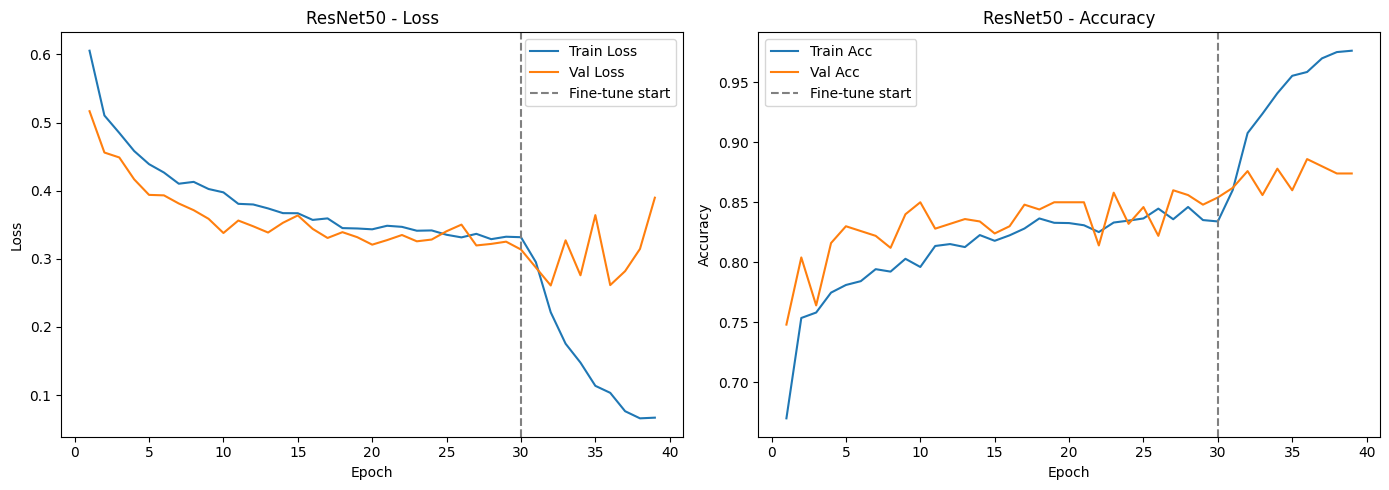

In [ ]:
def plot_history(h1, h2=None, title_prefix=''):
    train_loss = h1['train_loss'] + (h2['train_loss'] if h2 else [])
    val_loss = h1['val_loss'] + (h2['val_loss'] if h2 else [])
    train_acc= h1['train_acc'] + (h2['train_acc']if h2 else [])
    val_acc = h1['val_acc'] + (h2['val_acc'] if h2 else [])
    phase2_start = len(h1['train_loss']) if h2 else None
    epochs = range(1, len(train_loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, train_loss, label='Train Loss')
    ax1.plot(epochs, val_loss, label='Val Loss')
    if phase2_start:
        ax1.axvline(phase2_start, color='gray', linestyle='--', label='Fine-tune start')
    ax1.set_title(f'{title_prefix}Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, train_acc, label='Train Acc')
    ax2.plot(epochs, val_acc, label='Val Acc')
    if phase2_start:
        ax2.axvline(phase2_start, color='gray', linestyle='--', label='Fine-tune start')
    ax2.set_title(f'{title_prefix}Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('resnet50_training_curves.png', dpi=150)
    plt.show()

plot_history(history, history_ft, title_prefix='ResNet50 - ')

## 11. Evaluate on Test Set

In [ ]:
model.load_state_dict(torch.load(best_model_ft_path, weights_only=False))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)
TN, FP, FN, TP = cm.ravel()
FAR = FP / (FP + TN) if (FP + TN) > 0 else 0
FRR = FN / (FN + TP) if (FN + TP) > 0 else 0
class_names = full_dataset.classes

print('=' * 45)
print('        ResNet50 Test Results')
print('=' * 45)
print(f'  Accuracy:  {acc:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1-Score:  {f1:.4f}')
print(f'  FAR:       {FAR:.4f}  (lower is better)')
print(f'  FRR:       {FRR:.4f}')
print('=' * 45)
print()
print(classification_report(all_labels, all_preds, target_names=class_names))

        ResNet50 Test Results
  Accuracy:  0.9014
  Precision: 0.9127
  Recall:    0.8901
  F1-Score:  0.9013
  FAR:       0.0870  (lower is better)
  FRR:       0.1099

              precision    recall  f1-score   support

      forged       0.89      0.91      0.90       276
     genuine       0.91      0.89      0.90       282

    accuracy                           0.90       558
   macro avg       0.90      0.90      0.90       558
weighted avg       0.90      0.90      0.90       558



## 12. Confusion Matrix

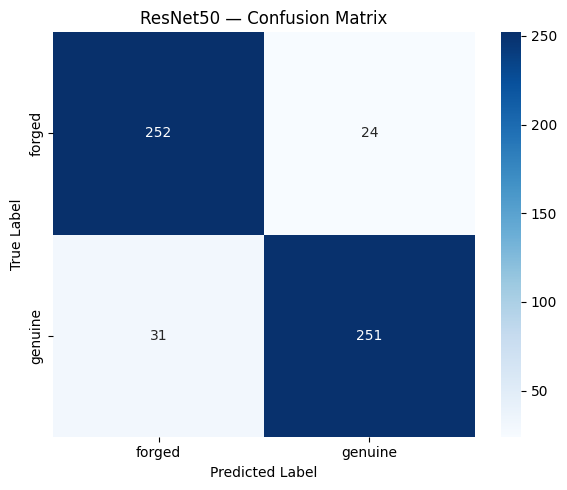

True Negatives  (Forged correctly rejected):  252
False Positives (Forged accepted as genuine): 24  <- FAR errors
False Negatives (Genuine rejected as forged): 31
True Positives  (Genuine correctly accepted): 251


In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('ResNet50 — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('resnet50_confusion_matrix.png', dpi=150)
plt.show()

print(f'True Negatives  (Forged correctly rejected):  {TN}')
print(f'False Positives (Forged accepted as genuine): {FP}  <- FAR errors')
print(f'False Negatives (Genuine rejected as forged): {FN}')
print(f'True Positives  (Genuine correctly accepted): {TP}')

## 13. Optimal Threshold Tuning

       Threshold Analysis
  Default threshold (0.50):
    FAR: 0.0870  FRR: 0.1099

  EER threshold (0.48):
    FAR ≈ FRR ≈ 0.0932

  Best accuracy threshold (0.44):
    Accuracy: 0.9158  FAR: 0.0942  FRR: 0.0745

  Low FAR threshold (0.59) [FRR ≤ 15%]:
    FAR: 0.0580  FRR: 0.1454


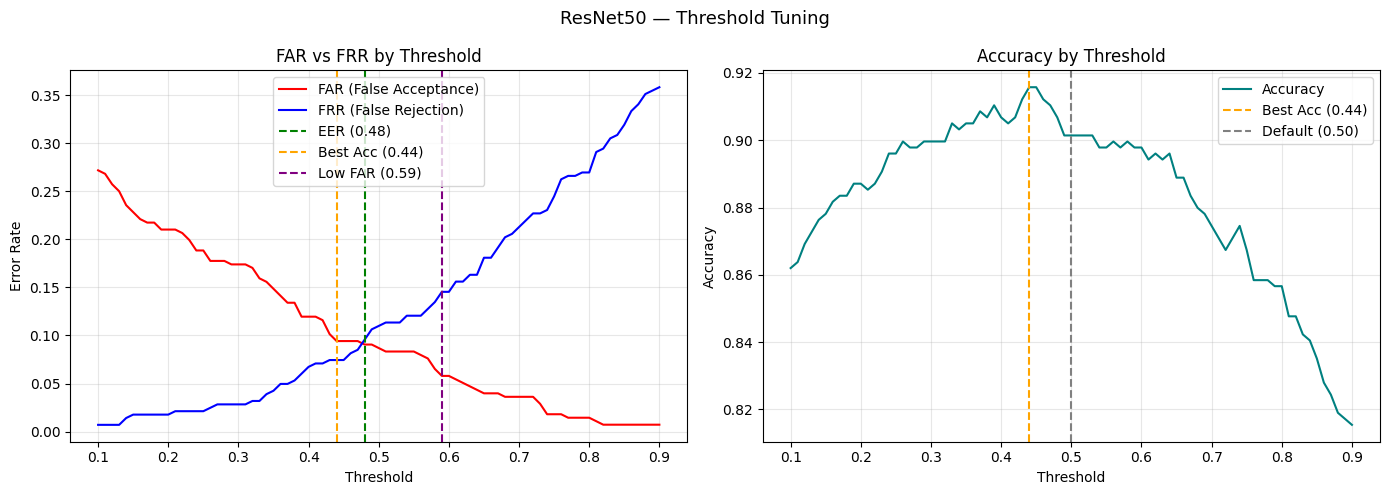


Optimal threshold set to: 0.5899999999999997
Use this value in the GUI for final predictions.


In [ ]:
# Threshold Tuning
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.1, 0.91, 0.01)

far_list = []
frr_list = []
acc_list = []

for thresh in thresholds:
    preds_t = (np.array(all_probs) >= thresh).astype(int)
    labels = np.array(all_labels)

    tn = ((preds_t == 0) & (labels == 0)).sum()
    fp = ((preds_t == 1) & (labels == 0)).sum()
    fn = ((preds_t == 0) & (labels == 1)).sum()
    tp = ((preds_t == 1) & (labels == 1)).sum()

    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0
    acc = (tp + tn) / len(labels)

    far_list.append(far)
    frr_list.append(frr)
    acc_list.append(acc)

far_arr = np.array(far_list)
frr_arr = np.array(frr_list)
acc_arr = np.array(acc_list)

# Find Equal Error Rate (EER) — where FAR ≈ FRR
eer_idx = np.argmin(np.abs(far_arr - frr_arr))
eer_threshold = thresholds[eer_idx]
eer_value = (far_arr[eer_idx] + frr_arr[eer_idx]) / 2

# Find threshold that maximises accuracy
best_acc_idx = np.argmax(acc_arr)
best_acc_thresh = thresholds[best_acc_idx]

# Find lowest FAR threshold where FRR stays under 15%
low_far_candidates = [(far_arr[i], thresholds[i]) for i in range(len(thresholds)) if frr_arr[i] <= 0.15]
low_far_thresh = min(low_far_candidates, key=lambda x: x[0])[1] if low_far_candidates else eer_threshold

print('=' * 50)
print('       Threshold Analysis')
print('=' * 50)
print(f'  Default threshold (0.50):')
print(f'    FAR: {far_arr[np.argmin(np.abs(thresholds - 0.5))]:.4f}  '
      f'FRR: {frr_arr[np.argmin(np.abs(thresholds - 0.5))]:.4f}')
print()
print(f'  EER threshold ({eer_threshold:.2f}):')
print(f'    FAR ≈ FRR ≈ {eer_value:.4f}')
print()
print(f'  Best accuracy threshold ({best_acc_thresh:.2f}):')
print(f'    Accuracy: {acc_arr[best_acc_idx]:.4f}  '
      f'FAR: {far_arr[best_acc_idx]:.4f}  '
      f'FRR: {frr_arr[best_acc_idx]:.4f}')
print()
print(f'  Low FAR threshold ({low_far_thresh:.2f}) [FRR ≤ 15%]:')
low_idx = np.argmin(np.abs(thresholds - low_far_thresh))
print(f'    FAR: {far_arr[low_idx]:.4f}  FRR: {frr_arr[low_idx]:.4f}')
print('=' * 50)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# FAR / FRR curve
ax1.plot(thresholds, far_arr, label='FAR (False Acceptance)', color='red')
ax1.plot(thresholds, frr_arr, label='FRR (False Rejection)', color='blue')
ax1.axvline(eer_threshold, color='green', linestyle='--', label=f'EER ({eer_threshold:.2f})')
ax1.axvline(best_acc_thresh, color='orange', linestyle='--', label=f'Best Acc ({best_acc_thresh:.2f})')
ax1.axvline(low_far_thresh, color='purple', linestyle='--', label=f'Low FAR ({low_far_thresh:.2f})')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Error Rate')
ax1.set_title('FAR vs FRR by Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(thresholds, acc_arr, color='teal', label='Accuracy')
ax2.axvline(best_acc_thresh, color='orange', linestyle='--', label=f'Best Acc ({best_acc_thresh:.2f})')
ax2.axvline(0.5, color='gray', linestyle='--', label='Default (0.50)')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy by Threshold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('ResNet50 — Threshold Tuning', fontsize=13)
plt.tight_layout()
plt.savefig('resnet50_threshold_tuning.png', dpi=150)
plt.show()

# Set optimal threshold for use in GUI
OPTIMAL_THRESHOLD = float(low_far_thresh)
print(f'\nOptimal threshold set to: {OPTIMAL_THRESHOLD}')
print('Use this value in the GUI for final predictions.')

## 14. Save Final Model

In [ ]:
# Load the best fine-tuned weights before saving final model
model.load_state_dict(torch.load(best_model_ft_path, weights_only=False))
save_path = '/content/drive/MyDrive/forged-signature-models/resnet50_signature_v3_5.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'optimal_threshold': OPTIMAL_THRESHOLD,
    'metrics': {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'FAR': FAR,
        'FRR': FRR
    }
}, save_path)
print(f'Model saved to: {save_path}')

Model saved to: /content/drive/MyDrive/forged-signature-models/resnet50_signature_v3_5.pth


## 15. Grad-CAM Visualisation

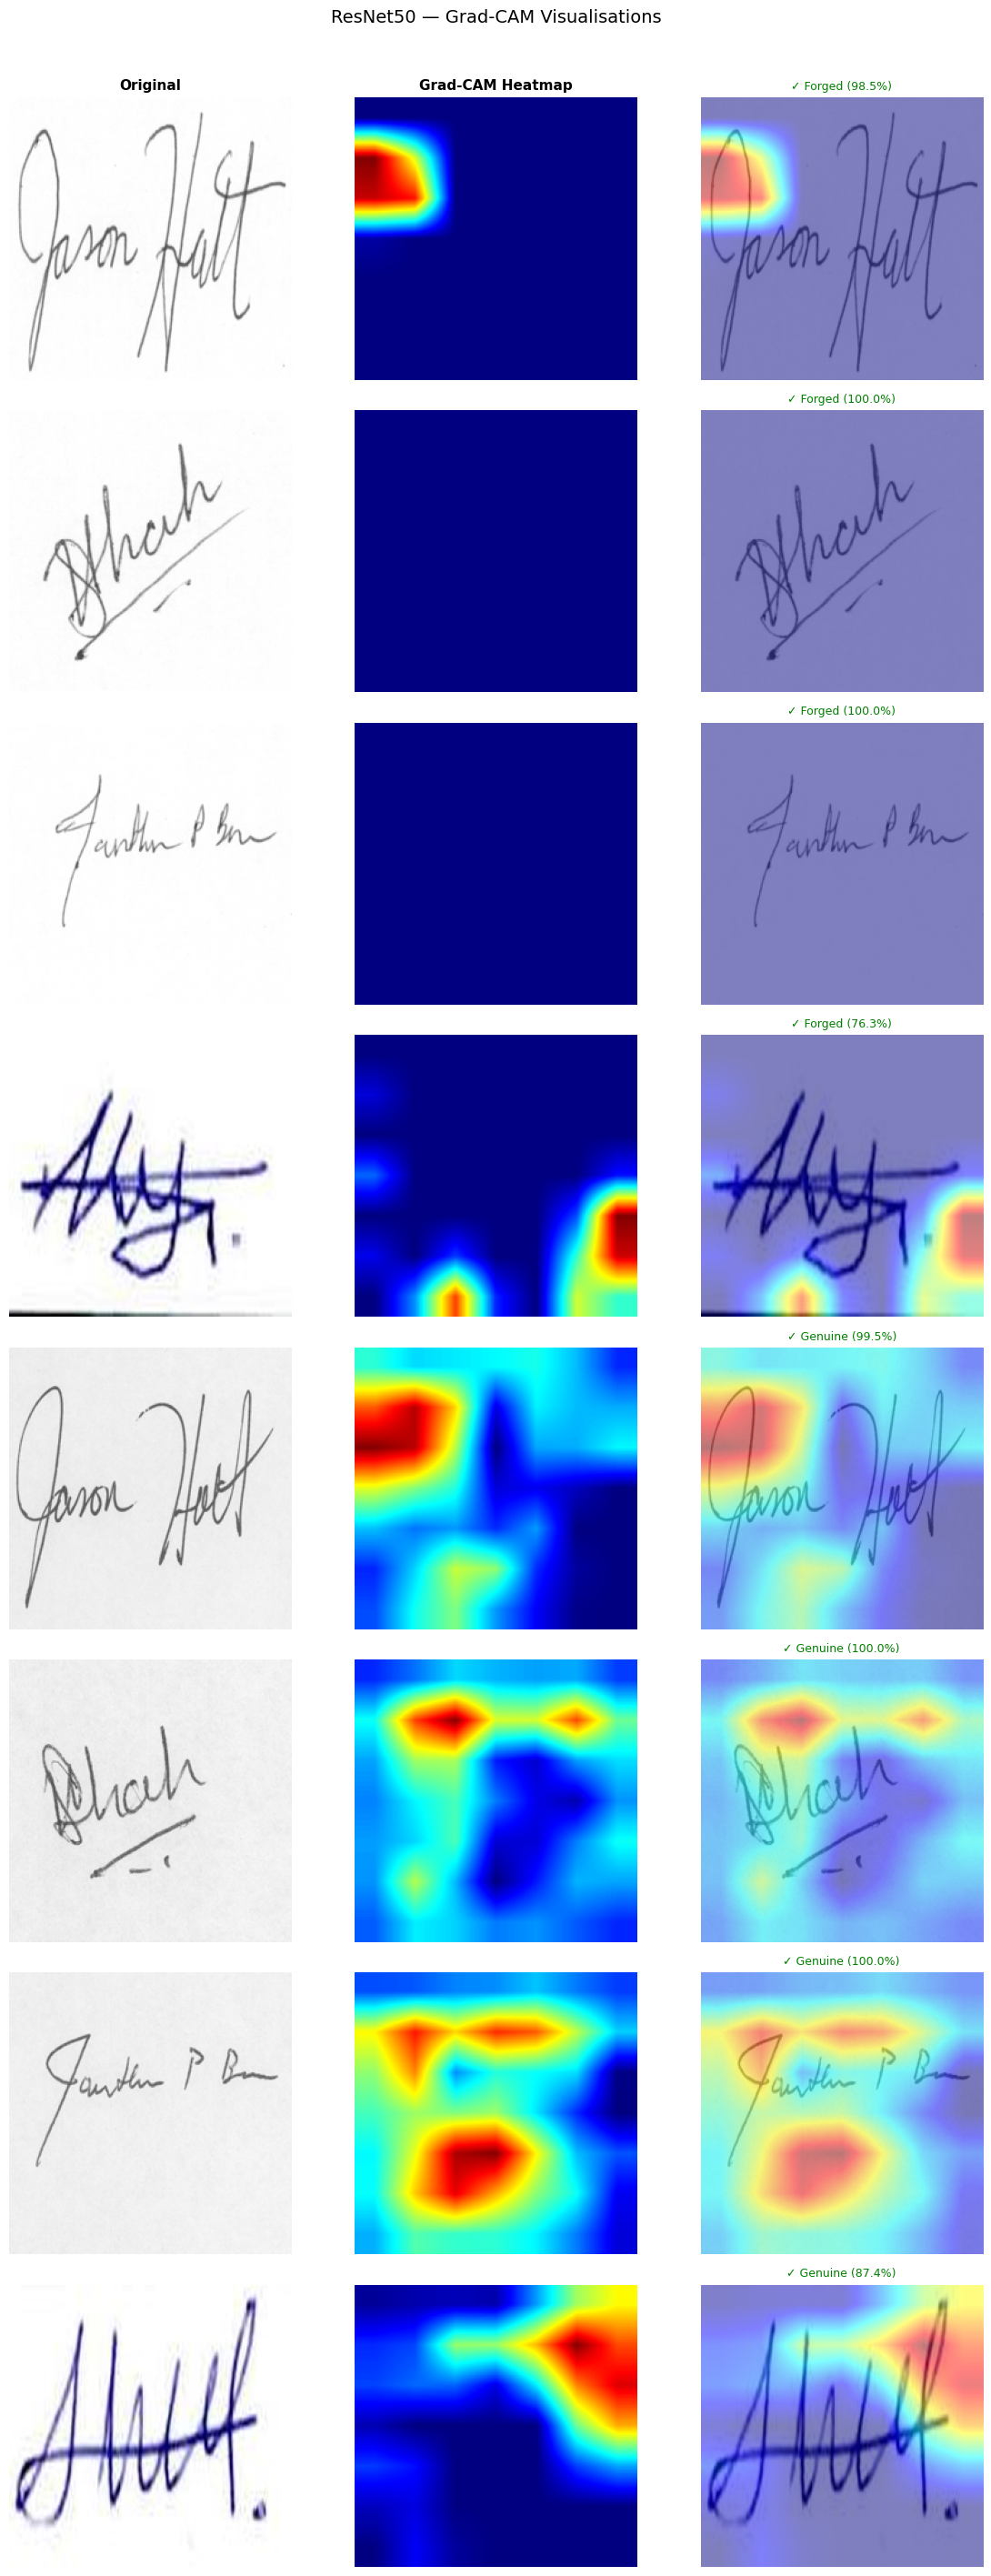

Grad-CAM saved.


In [ ]:
# Grad-CAM implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad()
        output[0, 0].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam).squeeze().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam

def predict_with_gradcam(image_path, model, gradcam):
    pil_img = Image.open(image_path).convert('RGB')
    tensor = val_test_transforms(pil_img).unsqueeze(0).to(device)
    tensor.requires_grad_(True)
    with torch.set_grad_enabled(True):
        output = model(tensor)
        prob = torch.sigmoid(output).item()
    pred_label = 'Genuine' if prob >= OPTIMAL_THRESHOLD else 'Forged'
    confidence = prob if pred_label == 'Genuine' else 1 - prob
    cam = gradcam.generate(tensor)
    img_np = np.array(pil_img.resize((224, 224)).convert('RGB'))
    heatmap = cv2.applyColorMap(np.uint8(255 * cv2.resize(cam, (224, 224))), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5 * img_np + 0.5 * heatmap).astype(np.uint8)
    return img_np, heatmap, overlay, pred_label, confidence

# Hook into last residual block of ResNet50 (layer4[-1])
gradcam = GradCAM(model, model.layer4[-1])

step = max(1, len(test_idx) // 8)
sample_indices = [test_idx[i * step] for i in range(8)]
sample_paths = [full_dataset.samples[i][0] for i in sample_indices]
sample_labels = [full_dataset.samples[i][1] for i in sample_indices]

fig, axes = plt.subplots(8, 3, figsize=(12, 28))
for ax, title in zip(axes[0], ['Original', 'Grad-CAM Heatmap', 'Overlay + Prediction']):
    ax.set_title(title, fontsize=11, fontweight='bold')

for i, (path, true_label) in enumerate(zip(sample_paths, sample_labels)):
    img_np, heatmap, overlay, verdict, conf = predict_with_gradcam(path, model, gradcam)
    true_name = class_names[true_label]
    correct = '✓' if verdict.lower() == true_name.lower() else '✗'
    color = 'green' if correct == '✓' else 'red'

    axes[i, 0].imshow(img_np); axes[i, 0].set_ylabel(f'True: {true_name}', fontsize=8); axes[i, 0].axis('off')
    axes[i, 1].imshow(heatmap); axes[i, 1].axis('off')
    axes[i, 2].imshow(overlay); axes[i, 2].set_title(f'{correct} {verdict} ({conf:.1%})', color=color, fontsize=9); axes[i, 2].axis('off')

plt.suptitle('ResNet50 — Grad-CAM Visualisations', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('resnet50_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grad-CAM saved.')

## 16. Reference Signature Comparison

Reference Signature Comparison Results
Signer: cedar_12 | Query: Genuine | Verdict: Genuine ✓ | Similarity: 0.8608 | Combined: 0.9277
Signer: cedar_12 | Query: Forged  | Verdict: Forged  ✓ | Similarity: 0.8733 | Combined: 0.4443
Signer: cedar_21 | Query: Genuine | Verdict: Genuine ✓ | Similarity: 0.9366 | Combined: 0.9683
Signer: cedar_21 | Query: Forged  | Verdict: Forged  ✓ | Similarity: 0.7429 | Combined: 0.3809
Signer: cedar_22 | Query: Genuine | Verdict: Genuine ✓ | Similarity: 0.8794 | Combined: 0.9397
Signer: cedar_22 | Query: Forged  | Verdict: Forged  ✓ | Similarity: 0.8178 | Combined: 0.4100
Signer: cedar_25 | Query: Genuine | Verdict: Genuine ✓ | Similarity: 0.9079 | Combined: 0.9539
Signer: cedar_25 | Query: Forged  | Verdict: Forged  ✓ | Similarity: 0.8052 | Combined: 0.4127


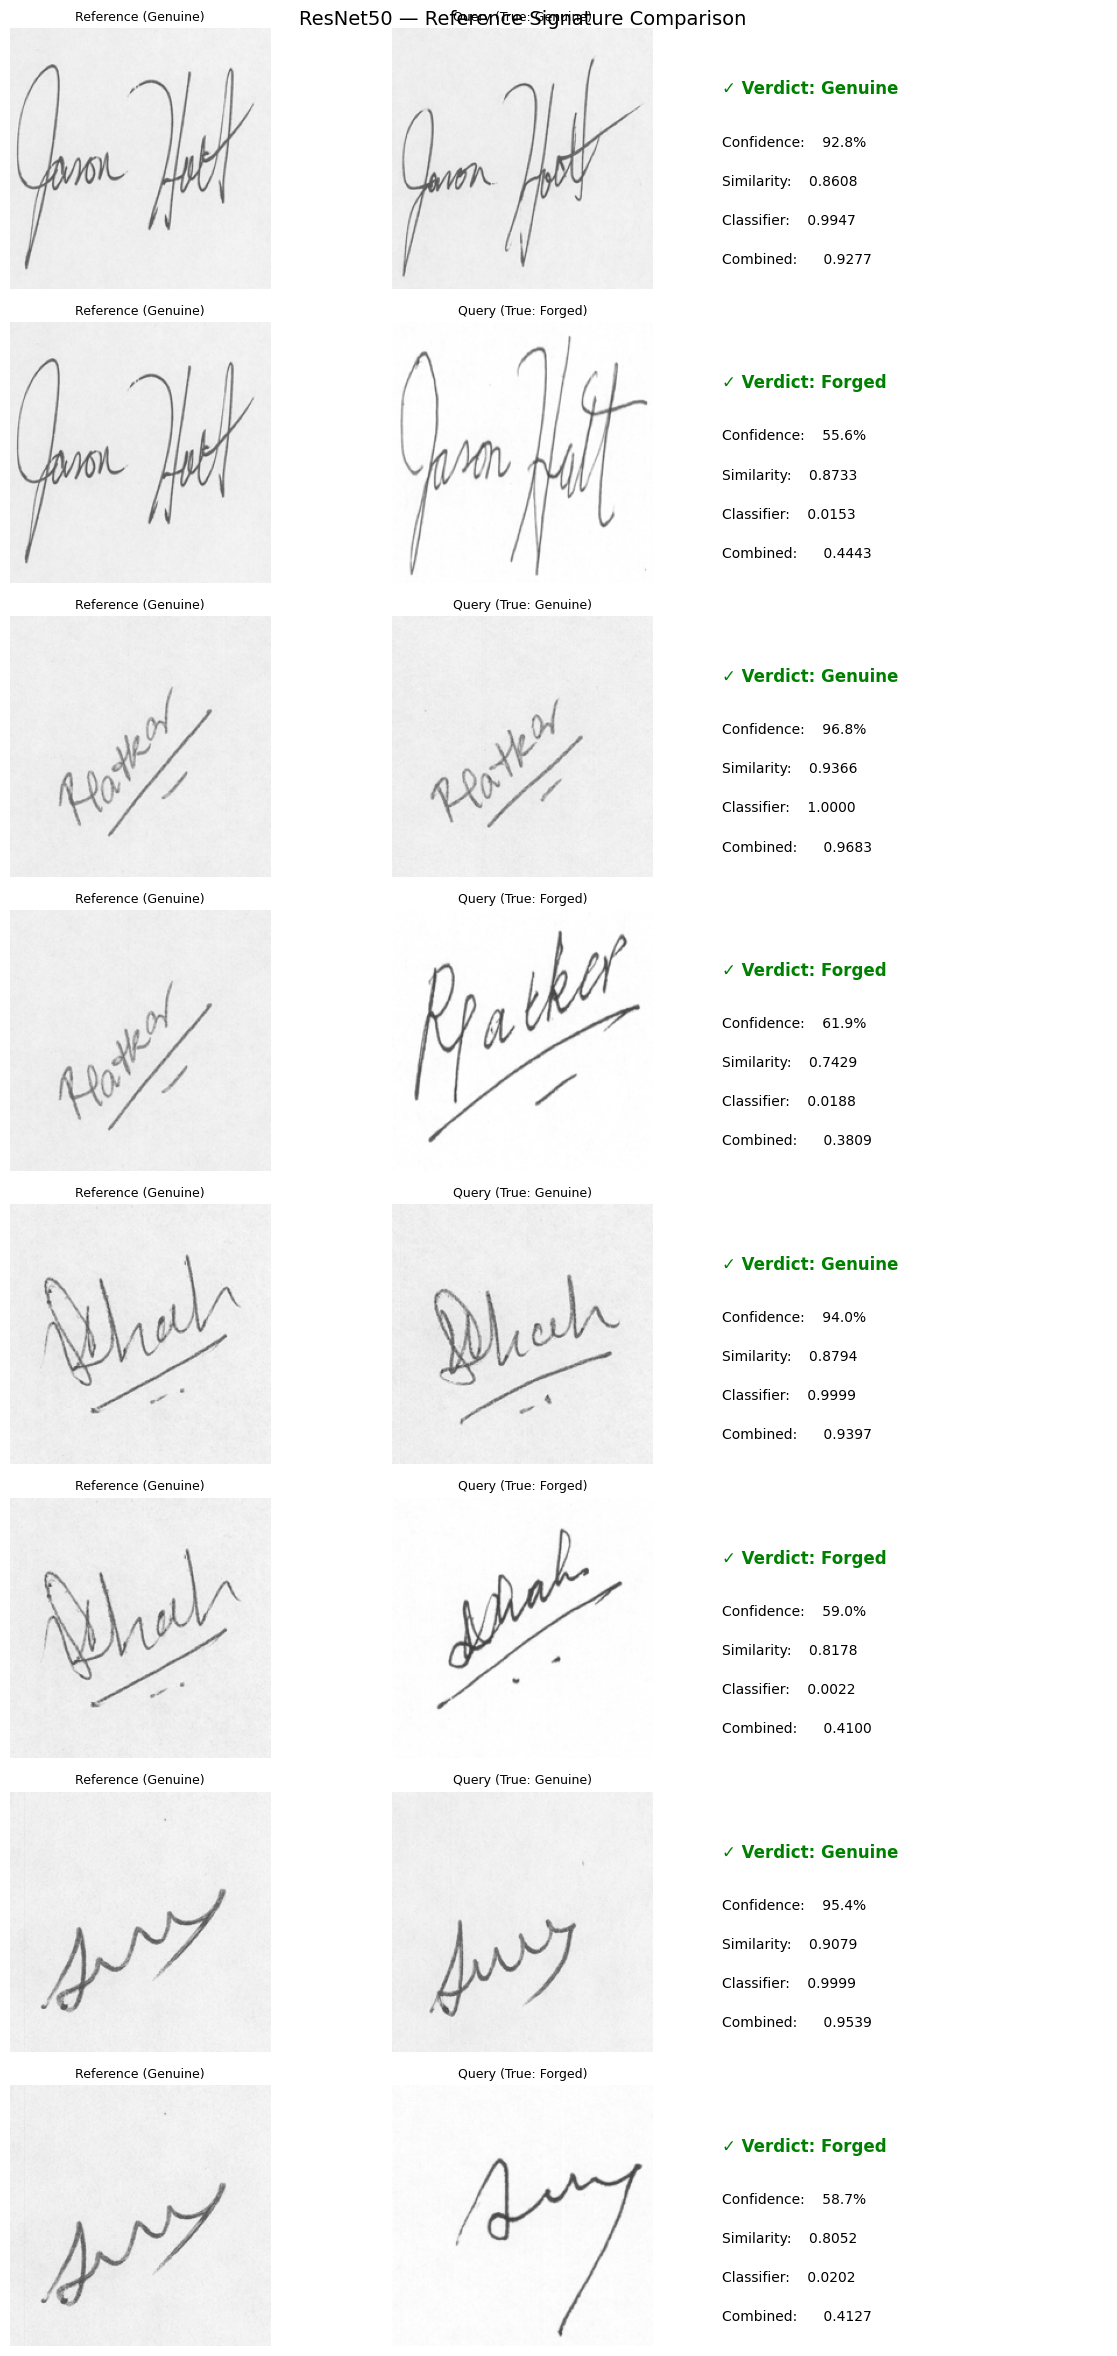


Reference comparison saved.


In [ ]:
# Reference Signature Comparison
class ResNetFeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        # Use everything up to (but not including) the fc head
        self.backbone = nn.Sequential(*list(model.children())[:-1])

    def forward(self, x):
        x = self.backbone(x)
        x = torch.flatten(x, 1)
        return x

feature_extractor = ResNetFeatureExtractor(model).to(device)
feature_extractor.eval()

def extract_embedding(image_path, transform):
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        embedding = feature_extractor(tensor)
    return embedding

def compare_signatures(ref_path, query_path, transform, threshold=OPTIMAL_THRESHOLD):
    ref_emb = extract_embedding(ref_path, transform)
    query_emb = extract_embedding(query_path, transform)

    similarity = cosine_similarity(ref_emb, query_emb).item()

    # Also run the classifier independently on the query
    img = Image.open(query_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
        classifier_prob = torch.sigmoid(output).item()

    # Combined score: weight similarity and classifier together
    combined_score = 0.5 * similarity + 0.5 * classifier_prob
    verdict = 'Genuine' if combined_score >= threshold else 'Forged'
    confidence = combined_score if verdict == 'Genuine' else 1 - combined_score

    return {
        'similarity':similarity,
        'classifier_prob': classifier_prob,
        'combined_score': combined_score,
        'verdict': verdict,
        'confidence': confidence
    }

# Build a lookup of genuine signatures per signer from the test set
from collections import defaultdict

signer_genuine = defaultdict(list)
signer_forged = defaultdict(list)

for idx in test_idx:
    path, label = full_dataset.samples[idx]
    signer = get_signer_id(path)
    if label == full_dataset.class_to_idx['genuine']:
        signer_genuine[signer].append(path)
    else:
        signer_forged[signer].append(path)

# Pick signers that have both genuine and forged samples in the test set
valid_signers = [s for s in signer_genuine if s in signer_forged][:4]

if len(valid_signers) == 0:
    raise RuntimeError(
        'valid_signers is empty — no test signer has both genuine and forged samples. '
        'Re-run cell 4 and check the class balance table to confirm test signers have both classes.'
    )

print('Reference Signature Comparison Results')
print('=' * 60)

fig, axes = plt.subplots(len(valid_signers) * 2, 3, figsize=(12, 6 * len(valid_signers)))
row = 0

for signer in valid_signers:
    ref_path = signer_genuine[signer][0]   # first genuine as reference
    genuine_path = signer_genuine[signer][1] if len(signer_genuine[signer]) > 1 else signer_genuine[signer][0]
    forged_path = signer_forged[signer][0]    # a forged sample

    for query_path, true_label in [(genuine_path, 'Genuine'), (forged_path, 'Forged')]:
        result = compare_signatures(ref_path, query_path, val_test_transforms)

        correct = '✓' if result['verdict'] == true_label else '✗'
        color = 'green' if correct == '✓' else 'red'

        # Reference image
        ref_img = np.array(Image.open(ref_path).convert('RGB').resize((224, 224)))
        query_img = np.array(Image.open(query_path).convert('RGB').resize((224, 224)))

        axes[row, 0].imshow(ref_img)
        axes[row, 0].set_title('Reference (Genuine)', fontsize=9)
        axes[row, 0].set_ylabel(f'Signer: {signer}', fontsize=8)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(query_img)
        axes[row, 1].set_title(f'Query (True: {true_label})', fontsize=9)
        axes[row, 1].axis('off')

        axes[row, 2].axis('off')
        axes[row, 2].text(0.05, 0.75, f'{correct} Verdict: {result["verdict"]}',
                          fontsize=12, color=color,
                          transform=axes[row, 2].transAxes, fontweight='bold')
        axes[row, 2].text(0.05, 0.55, f'Confidence:    {result["confidence"]:.1%}',
                          fontsize=10, transform=axes[row, 2].transAxes)
        axes[row, 2].text(0.05, 0.40, f'Similarity:    {result["similarity"]:.4f}',
                          fontsize=10, transform=axes[row, 2].transAxes)
        axes[row, 2].text(0.05, 0.25, f'Classifier:    {result["classifier_prob"]:.4f}',
                          fontsize=10, transform=axes[row, 2].transAxes)
        axes[row, 2].text(0.05, 0.10, f'Combined:      {result["combined_score"]:.4f}',
                          fontsize=10, transform=axes[row, 2].transAxes)

        print(f'Signer: {signer} | Query: {true_label:7s} | '
              f'Verdict: {result["verdict"]:7s} {correct} | '
              f'Similarity: {result["similarity"]:.4f} | '
              f'Combined: {result["combined_score"]:.4f}')
        row += 1

plt.suptitle('ResNet50 — Reference Signature Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('resnet50_reference_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nReference comparison saved.')

## 17. Similarity Distribution Analysis

Computing embeddings for all test pairs...


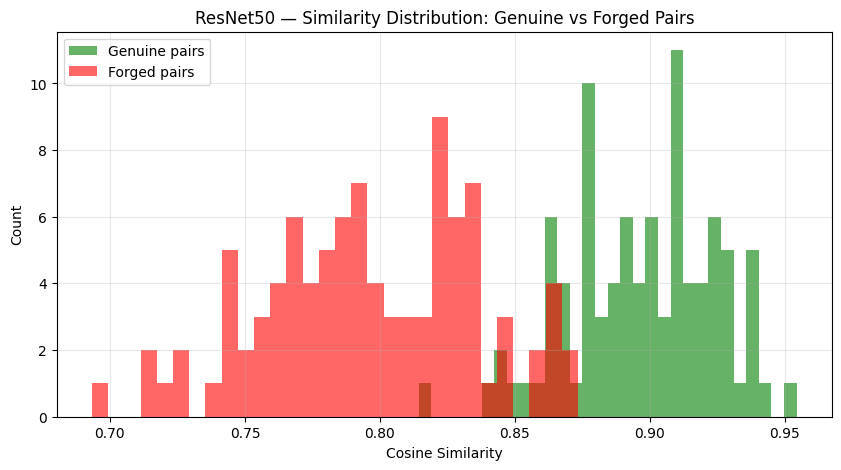


Genuine pairs — Mean: 0.8966  Std: 0.0267
Forged pairs  — Mean: 0.7965  Std: 0.0394
Separation gap: 0.1002


In [ ]:
from torch.nn.functional import cosine_similarity as cos_sim

similarities_genuine = []
similarities_forged = []

print('Computing embeddings for all test pairs...')

for signer in valid_signers:
    ref_path = signer_genuine[signer][0]
    ref_emb = extract_embedding(ref_path, val_test_transforms)

    # Genuine queries
    for path in signer_genuine[signer][1:]:
        emb = extract_embedding(path, val_test_transforms)
        sim = cos_sim(ref_emb, emb).item()
        similarities_genuine.append(sim)

    # Forged queries
    for path in signer_forged[signer]:
        emb = extract_embedding(path, val_test_transforms)
        sim = cos_sim(ref_emb, emb).item()
        similarities_forged.append(sim)

# Plot distributions
plt.figure(figsize=(10, 5))
plt.hist(similarities_genuine, bins=30, alpha=0.6, color='green', label='Genuine pairs')
plt.hist(similarities_forged, bins=30, alpha=0.6, color='red', label='Forged pairs')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.title('ResNet50 — Similarity Distribution: Genuine vs Forged Pairs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('resnet50_similarity_distribution.png', dpi=150)
plt.show()

print(f'\nGenuine pairs — Mean: {np.mean(similarities_genuine):.4f}  Std: {np.std(similarities_genuine):.4f}')
print(f'Forged pairs  — Mean: {np.mean(similarities_forged):.4f}  Std: {np.std(similarities_forged):.4f}')
print(f'Separation gap: {np.mean(similarities_genuine) - np.mean(similarities_forged):.4f}')